<a href="https://colab.research.google.com/github/Cato-8/Customer-Churn-Analysis/blob/main/week7_%3CMarvi_Malik%3E_Naive_Baye's.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:Marvi Malik**
**Student ID:023-24-0016**
**Section:B**
**GitHub:**
**Kaggle:**
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [17]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [18]:
# Task 1 — load spam.csv, inspect shape/head/class balance
df_spam = pd.read_csv('/content/spam.csv', encoding='latin-1')
print(df_spam.shape)
print(df_spam.head)
print(df_spam['v1'].value_counts())




(5572, 5)
<bound method NDFrame.head of         v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN   

In [19]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
df_tweet = pd.read_csv('/content/Tweets.csv')
df_tweet = df_tweet[df_tweet['airline_sentiment'] != 'neutral']
print(df_tweet.shape)
print(df_tweet.head)
print(df_tweet['airline_sentiment'].value_counts())

(11541, 15)
<bound method NDFrame.head of                  tweet_id airline_sentiment  airline_sentiment_confidence  \
1      570301130888122368          positive                        0.3486   
3      570301031407624196          negative                        1.0000   
4      570300817074462722          negative                        1.0000   
5      570300767074181121          negative                        1.0000   
6      570300616901320704          positive                        0.6745   
...                   ...               ...                           ...   
14633  569587705937600512          negative                        1.0000   
14634  569587691626622976          negative                        0.6684   
14635  569587686496825344          positive                        0.3487   
14636  569587371693355008          negative                        1.0000   
14638  569587188687634433          negative                        1.0000   

               negativereason  ne

**Answer 2 (Task A — spam):**
_(The pactical problem being solved in task A is identifyng spam and not spam emails and it is binary classification because its output can be either of two i.e. apam or not spam.)_

**Answer 2 (Task B — sentiment):**
_(Here pratical problem being solved is telling that whether a tweet sentiment is positive or negative that is also the reason behind this problem being binary cassification as output an be only from these two.)_

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [20]:
# Task 3 — clean text
txt=df_spam['v2'].str.lower()
print(txt)


0       go until jurong point, crazy.. available only ...
1                           ok lar... joking wif u oni...
2       free entry in 2 a wkly comp to win fa cup fina...
3       u dun say so early hor... u c already then say...
4       nah i don't think he goes to usf, he lives aro...
                              ...                        
5567    this is the 2nd time we have tried 2 contact u...
5568                will ì_ b going to esplanade fr home?
5569    pity, * was in mood for that. so...any other s...
5570    the guy did some bitching but i acted like i'd...
5571                           rofl. its true to its name
Name: v2, Length: 5572, dtype: object


In [21]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
labels=df_spam['v1']
labels=labels.map({'ham':0,'spam':1})
X_train, X_test, y_train, y_test = train_test_split(txt, labels, test_size=0.2, random_state=42)
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)
vocab_size = len(vectorizer.get_feature_names_out())
print(vocab_size)



7735


**Answer 4 (why fit on training data only):**
_(The vectorizer is fit only on training data (vocabulary size: 7735 features) to avoid leaking test data information into the model. If we fit it on everything, the model would "see" test words in advance, making results look better than they'd really be on new, unseen messages.)_

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy: 0.984
Precision: 0.985
Recall: 0.893
F1-score: 0.937


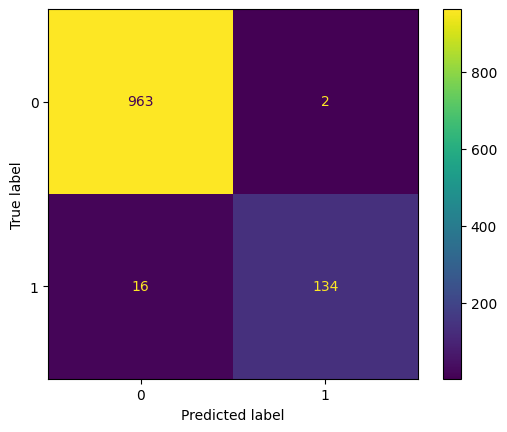

In [22]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)
y_pred = model.predict(X_test_vectorized)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", round(accuracy,3))
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-score:", round(f1,3))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()


**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.984 |
| Precision |0.985 |
| Recall |0.893 |
| F1-score |0.937 |

**Answer 6:**
_(A false positive (real message wrongly marked as spam) is worse here, because the user might miss an important message that got hidden in spam folder. A false negative (spam getting through) is just annoying, not harmful. So precision matters more than recall, we want to be very sure before calling something spam. Our model already has high precision (0.985), which is good for this reason.)_

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [23]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
feature_log_prob = model.feature_log_prob_
spam_words = np.argsort(feature_log_prob[1])[-15:]
ham_words = np.argsort(feature_log_prob[0])[-15:]
spam_words_list = vectorizer.get_feature_names_out()[spam_words]
ham_words_list = vectorizer.get_feature_names_out()[ham_words]
print("Top spam words:", spam_words_list)
print("Top ham words:", ham_words_list)



Top spam words: ['from' 'have' 'ur' 'on' 'is' 'txt' 'or' 'now' 'the' 'for' 'free' 'your'
 'you' 'call' 'to']
Top ham words: ['but' 'have' 'so' 'for' 'of' 'that' 'it' 'is' 'my' 'me' 'in' 'and' 'the'
 'to' 'you']


**Answer 7:**
_(Some spam words make sense , "free", "call", "txt", "ur" match typical spam patterns (offers, urgency, informal texting style). But the list also has a lot of common words like "the", "for", "is", "on" which don't feel spam-specific, same for the ham list. This is because these are just the highest-probability words overall in each class, not words that are uniquely distinguishing between spam and ham (a better method would rank by the difference between spam and ham log-probabilities, not just raw probability). So intuition is only partly confirmed here.)_

In [24]:
# Task 8 — test your own messages
my_messages = [
    # "your spam-like message here",
    "Congratulations! You've won a free prize, call now to claim your reward!",
    # "your normal message here",
     "Hey, are we still meeting for lunch tomorrow?"
]
my_messages_vectorized = vectorizer.transform(my_messages)
my_predictions = model.predict(my_messages_vectorized)
print("Predictions for your messages:", my_predictions)



Predictions for your messages: [1 0]


**Answer 8:**
_(Both predictions matched expectations, the spam-like message (prize/call-now) was predicted as SPAM (1), and the normal lunch message was predicted as HAM (0). This confirms the model correctly picked up on common spam signals like "free," "call," and urgency-style wording.)_

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
_(https://www.kaggle.com/code/marvimalik/notebook66d1a0fff0/edit)_

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [26]:
# Task 11 — clean and vectorize the sentiment data (your own approach)
df_tweet['text'] = df_tweet['text'].str.lower()
X_train, X_test, y_train, y_test = train_test_split(df_tweet['text'], df_tweet['airline_sentiment'], test_size=0.2, random_state=42)
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)
vocab_size = len(vectorizer.get_feature_names_out())
print(vocab_size)




11150


**Answer 12:**
_(Beyond lowercasing, tweets contain @mentions (like @united) and links which don't carry real sentiment meaning, so removing them helps the vectorizer focus on actual sentiment-carrying words instead of noise (e.g. different usernames would otherwise be treated as unique features, bloating the vocabulary). SMS spam messages didn't have this problem since they're plain text without)_

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

Accuracy: 0.915
Precision: 0.914
Recall: 0.915
F1-score: 0.908


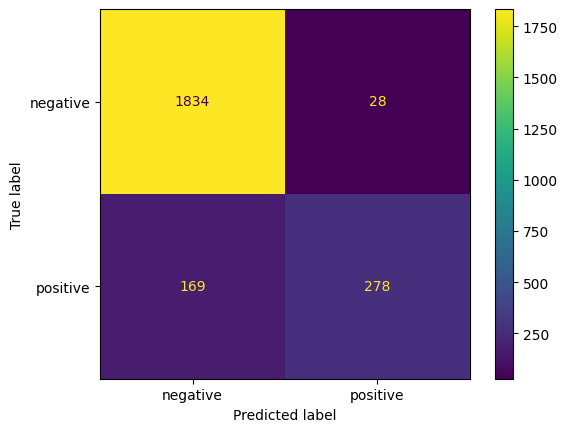

In [28]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)
y_pred = model.predict(X_test_vectorized)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print("Accuracy:", round(accuracy,3))
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-score:", round(f1,3))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()



**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.915 |
| Precision |0.914 |
| Recall |0.915 |
| F1-score |0.908 |

**Answer 14:**
_(Naive Bayes did worse on sentiment (91.5% accuracy, F1=0.908) than on spam (98.4% accuracy, F1=0.937). This connects directly to the "naive" independence assumption: spam SMS messages tend to have simple, formulaic patterns (specific keywords like "free" or "call" strongly signal spam on their own), so treating words as independent works well. Tweets are harder because sentiment often depends on word combinations and context i.e.sarcasm, negation ("not good" vs "good"), and tone can flip meaning in ways a bag-of-independent-words model can't capture. So the independence assumption is less reasonable for sentiment analysis than for spam detection, which explains the performance gap.)_

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
_(https://www.kaggle.com/code/marvimalik/notebookd0be6cbc41/edit)_

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | 0.984 | 0.915 |
| Precision | 0.985 | 0.914 |
| Recall | 0.893 | 0.915 |
| F1-score | 0.937 | 0.908 |

Accuracy: 0.922
Precision: 0.92
Recall: 0.922
F1-score: 0.921


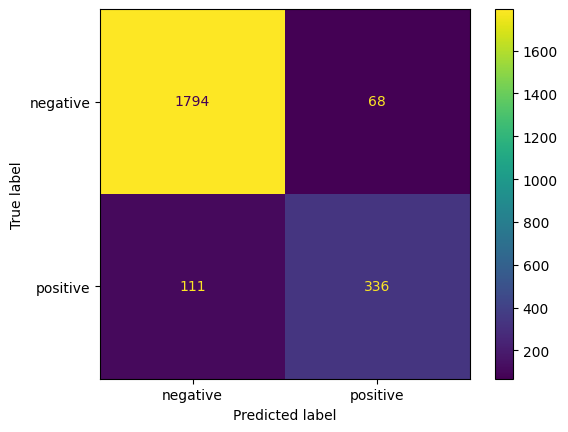

In [29]:
# Task 18 — train Logistic Regression on Task A's vectorized features
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vectorized, y_train)
y_pred = model.predict(X_test_vectorized)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print("Accuracy:", round(accuracy,3))
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1-score:", round(f1,3))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()



**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | 0.984 | 0.922 |
| Precision | 0.985 | 0.920 |
| Recall | 0.893 | 0.922 |
| F1-score | 0.937 | 0.921 |

**Answer 18 (which wins, and does it match expectations):**
_(Naive Bayes wins here, beating Logistic Regression on every metric (accuracy 0.984 vs 0.922, F1 0.937 vs 0.921). This does match expectations means spam detection has short, formulaic messages where specific keywords ("free", "call", "txt") independently and strongly signal spam, which is exactly the setting Naive Bayes's independence assumption works well in. Logistic Regression, which models more complex relationships between features, doesn't have a natural advantage here since the text doesn't need that extra complexity, so the simpler, faster Naive Bayes model performs just as well or better.)_

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
_(Naive Bayes worked better on spam detection (Task A, 98.4% accuracy) than sentiment analysis (Task B, 91.5% accuracy), because spam messages have short, keyword-driven patterns that fit the independence assumption well, while tweets need context and word order to judge sentiment properly. What surprised me about the top predictive words was that many were just common everyday words ("the", "is", "for") rather than clearly spam-specific terms which shows this happened because the words were picked by highest raw probability, not by the biggest difference between spam and ham. Comparing to Logistic Regression, Naive Bayes actually outperformed it on)_

**Answer 20 — Kaggle Notebook Links:**
- Task A: (https://www.kaggle.com/code/marvimalik/notebook66d1a0fff0/edit)
- Task B: (https://www.kaggle.com/code/marvimalik/notebookd0be6cbc41/edit)

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [ ] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [ ] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [ ] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [ ] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published and linked
- [ ] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [ ] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published and linked
- [ ] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [ ] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted